По трем значениям случайного вектора:

a) найти уравнение линейной регрессии 

In [4]:
import numpy as np
from scipy import stats

y = np.array([1,5,2])
psi = np.array([[1,0], [0,1], [1, 1]])
F = psi.T @ psi

F_inv = np.linalg.inv(F)


In [5]:
beta = F_inv @ psi.T @ y
print(beta)

[-0.33333333  3.66666667]


In [10]:
print(beta @ psi.T)

[-0.33333333  3.66666667  3.33333333]


b) rigde-регрессия

найдем alpha по кросс-валидации

21.265098855359007
1.5000000000000002


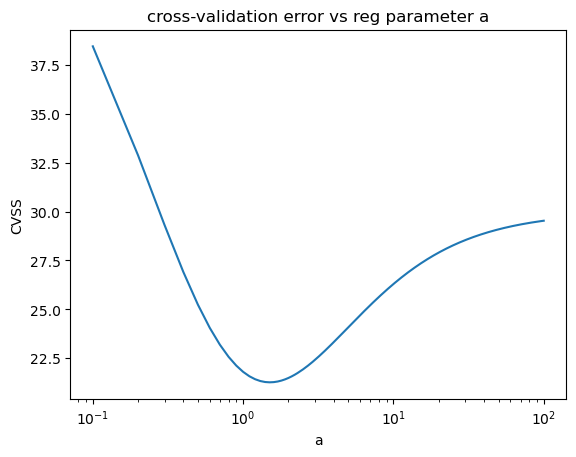

In [26]:
import matplotlib.pyplot as plt

n = 3
CVSS_array = []
a_array = []
E = np.array([[1, 0], [0,1]])
for a in np.arange(0.1, 100, 0.1):
    CVSS = 0
    for i in range(n):
        #убираем i-ое наблюдение
        psi_train = np.delete(psi, i, axis=0)
        eta_train = np.delete(y, i)

        F_train = psi_train.T @ psi_train
        F_train_inv = np.linalg.inv(F_train + a * E)
        beta = F_train_inv @ psi_train.T @ eta_train
        
        y_pred = psi[i] @ beta

        CVSS += (y[i] - y_pred) ** 2
    CVSS_array.append(CVSS)
    a_array.append(a)
print(np.min(CVSS_array))
print(a_array[np.argmin(CVSS_array)])

plt.plot(a_array, CVSS_array)
plt.xscale('log')
plt.xlabel('a')
plt.ylabel('CVSS')
plt.title('cross-validation error vs reg parameter a')
plt.show()

In [27]:
a_min = a_array[np.argmin(CVSS_array)]
F_reg = F + a_min * E
F_reg_inv = np.linalg.inv(F_reg)
beta_reg = F_reg_inv @ psi.T @ y
print(beta_reg)

[0.31111111 1.91111111]


с) lasso-регрессия (нет аналитической формулы)

In [33]:
from sklearn.linear_model import Lasso

a_array = []
CVSS_array = []

for a in np.arange(0.01, 10, 0.01):
    CVSS = 0
    for i in range(n):
        psi_train = np.delete(psi, i, axis=0)
        eta_train = np.delete(y, i)
        
        model = Lasso(alpha=a, fit_intercept=False)
        model.fit(psi_train, eta_train)
        y_pred = model.predict(psi[i].reshape(1, -1))
        
        CVSS += float((y[i] - y_pred[0]) ** 2)
    
    a_array.append(a)
    CVSS_array.append(CVSS)

a_min = float(a_array[np.argmin(CVSS_array)])
print(f"alpha = {a_min}, CVSS = {min(CVSS_array)}")

alpha = 1.5, CVSS = 26.0


In [34]:
model = Lasso(alpha=a_min, fit_intercept=False)
model.fit(psi, y)
print(model.coef_)

[0.   1.25]


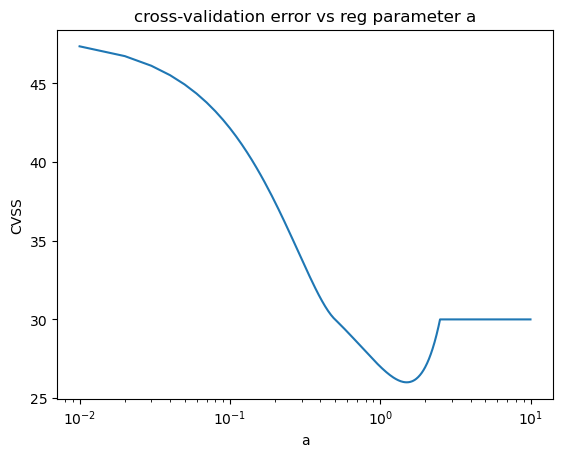

In [35]:
plt.plot(a_array, CVSS_array)
plt.xscale('log')
plt.xlabel('a')
plt.ylabel('CVSS')
plt.title('cross-validation error vs reg parameter a')
plt.show()